![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [1]:
#!sudo apt-get install libgomp1
#!sudo apt-get install libxft2
#!sudo apt-get install libglu1

Run everytime you start to execute this Jupyter Notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

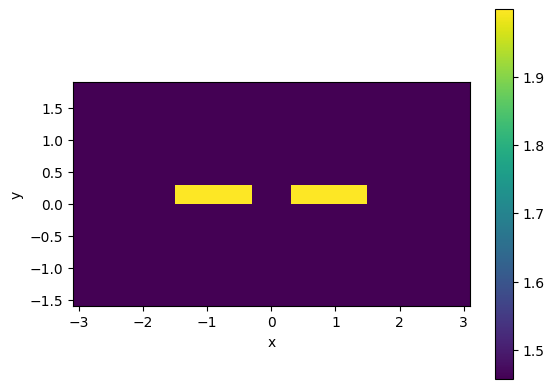

In [4]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [16]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-05-01 20:14:56.577 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_cbc1bb971a882eda.npz.
[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [17]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [18]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

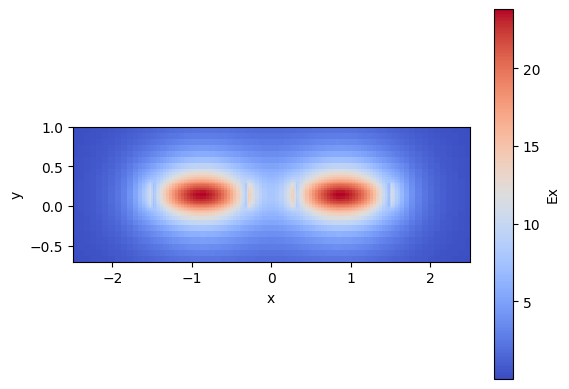

In [19]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

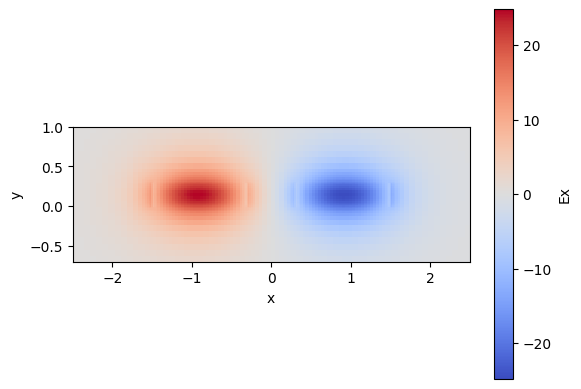

In [20]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

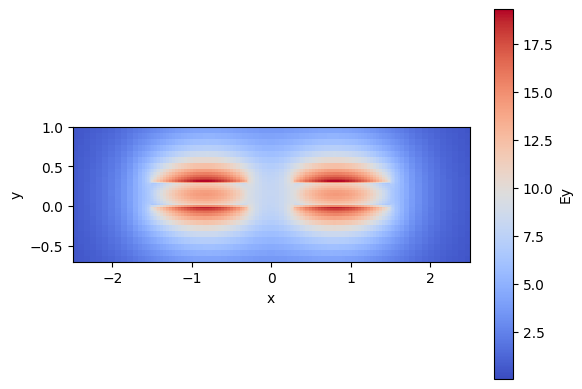

In [21]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

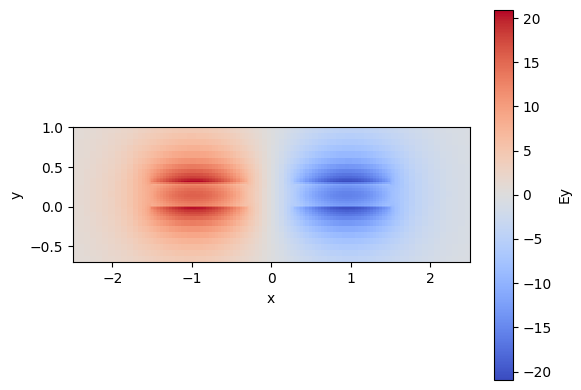

In [22]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [23]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536699492
52.260223677445325


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [24]:
dcoupler_cs.coupling_length()

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

L_pi_TE  = 93.838 µm
L_pi_TM  = 52.260 µm
complete exchange at L ≃ 93.8 µm
50/50 split at L ≃ 46.9 µm


<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_13357/1512399786.py:18: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('L / L$_\pi$')


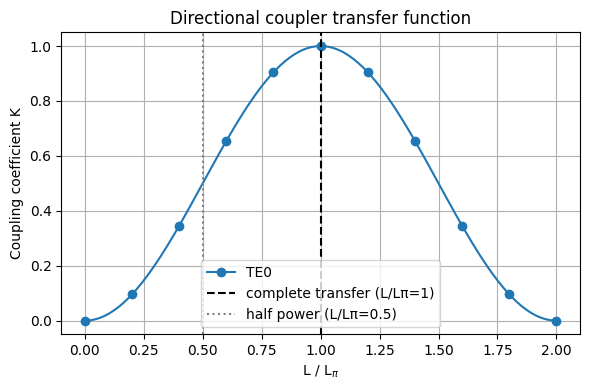

In [25]:
# LO.2 – transfer function K vs L/Lpi for the directional coupler

# we already have the beating length for the TE pair
print("L_pi_TE  = {:.3f} µm".format(L_pi_TE))
print("L_pi_TM  = {:.3f} µm".format(L_pi_TM))

# construct a set of length ratios (L/L_pi) and compute K
ratio = np.linspace(0, 2, 201)            # from 0 to twice the coupling length
K = np.sin(np.pi/2 * ratio)**2            # K = sin^2[(π/2)·(L/Lπ)]

# physical lengths corresponding to the TE case
L_values = ratio * L_pi_TE

plt.figure(figsize=(6,4))
plt.plot(ratio, K, '-o', markevery=20, label='TE0')
plt.axvline(1, color='k', ls='--', label='complete transfer (L/Lπ=1)')
plt.axvline(0.5, color='gray', ls=':', label='half power (L/Lπ=0.5)')
plt.xlabel('L / L$_\pi$')
plt.ylabel('Coupling coefficient K')
plt.title('Directional coupler transfer function')
plt.grid(True)
plt.legend()
plt.tight_layout()

# print a couple of noteworthy lengths
print("complete exchange at L ≃ {:.1f} µm".format(L_pi_TE))
print("50/50 split at L ≃ {:.1f} µm".format(0.5*L_pi_TE))

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [26]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.8 # Student. Gap between waveguides
wg_width = 1 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  104.3142404197827  µm


/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1043 [00:00<?, ?it/s]

------- Pameters -------
MMI length 52.1571
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9640
Total OUT power: 0.9644
Excess loss [dB] =  0.1574
------------------------
Power over OUTs:  ['0.4821', '0.4823']
Ratio over OUTs ['0.4999', '0.5001']


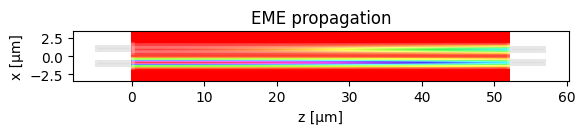

In [27]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: Comple

gaps: [0.2 0.4 0.6 0.8 1.  1.2]
L_pi: [np.float64(17.661592174257745), np.float64(32.674957695064066), np.float64(58.77841253851097), np.float64(104.31424041976399), np.float64(183.3130270778812), np.float64(319.73923615071175)]


/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


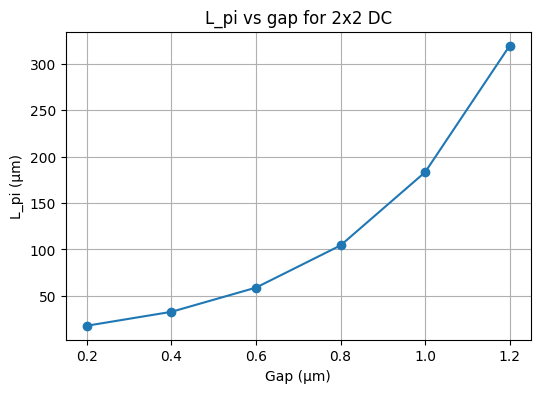

In [28]:
import matplotlib.pyplot as plt

gaps = np.arange(0.2, 1.21, 0.2)  
Lpi_vals = []

for gap in gaps:
    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = wg_N
    m.find_all_modes()
    Lpi_vals.append(m.get_L_pi())

plt.figure(figsize=(6,4))
plt.plot(gaps, Lpi_vals, '-o')
plt.xlabel('Gap (µm)')
plt.ylabel('L_pi (µm)')
plt.title('L_pi vs gap for 2x2 DC')
plt.grid(True)

print('gaps:', gaps)
print('L_pi:', Lpi_vals)


## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



CONDICIÓN TEÓRICA PARA GUÍAS DESACOPLADAS
K objetivo            = 0.01
Longitud paralela (L) = 10.0 mm
Lpi mínimo requerido  = 156.82 mm
Delta n_eff máximo    = 4.942e-06
Simulando Deep WG - gap = 0.2 um...
2026-05-01 20:16:55.970 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_c735717a8742a223.npz.
Simulando Deep WG - gap = 0.4 um...
2026-05-01 20:16:55.980 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f0903b36a6669153.npz.
Simulando Deep WG - gap = 0.6 um...
2026-05-01 20:16:55.992 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_40b89b65a6f22400.npz.


Simulando Deep WG - gap = 0.8 um...
2026-05-01 20:16:55.997 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_16be99bd3e78a9eb.npz.
Simulando Deep WG - gap = 1.0 um...
2026-05-01 20:16:56.008 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_81cd52b7728ca66a.npz.
Simulando Deep WG - gap = 1.2 um...
2026-05-01 20:16:56.018 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_591cb4dce0a44c14.npz.
Simulando Deep WG - gap = 1.4 um...
2026-05-01 20:16:56.026 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_5bcf328525751418.npz.
Simulando Deep WG - gap = 1.6 um...
2026-05-01 20:16:56.036 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_1a9045dcc5745bad.npz.
Simulando Deep WG - gap = 1.8 um...
2026-05-01 20:16:56.046 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_30a82f630f6a3d

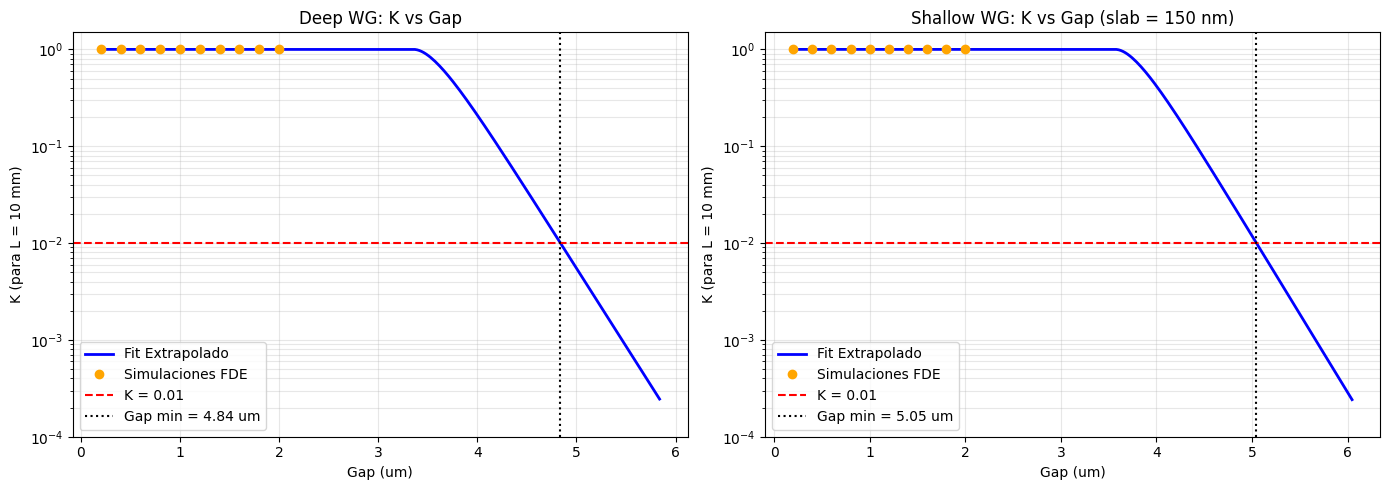


** RESULTADOS FINALES: GAP MÍNIMO REQUERIDO **
Deep waveguide    -> Gap mínimo = 4.84 um
Shallow waveguide -> Gap mínimo = 5.05 um


In [29]:
# LO.4 - Parallel uncoupled waveguides - TE0 mode

try:
    nm
except NameError:
    nm = 1e-3

# Parámetros del enunciado
lambda_lo4 = 1.55      # um
wg_width_lo4 = 1.0     # um
core_h_lo4 = 300 * nm  # 0.3 um

L_parallel = 10_000    # um = 10 mm
K_target = 0.01

slab_deep = 0 * nm
slab_shallow = 150 * nm

# Cálculo teórico del Lpi necesario para tener K = 0.01
# K = sin^2((pi/2)*(L/Lpi))
L_over_Lpi_limit = (2 / np.pi) * np.arcsin(np.sqrt(K_target))
Lpi_required = L_parallel / L_over_Lpi_limit
dneff_required = lambda_lo4 / (2 * Lpi_required)

print("="*60)
print("CONDICIÓN TEÓRICA PARA GUÍAS DESACOPLADAS")
print("="*60)
print(f"K objetivo            = {K_target}")
print(f"Longitud paralela (L) = {L_parallel/1000:.1f} mm")
print(f"Lpi mínimo requerido  = {Lpi_required/1000:.2f} mm")
print(f"Delta n_eff máximo    = {dneff_required:.3e}")
print("="*60)


# Barrido moderado (hasta 2.0 um es suficiente para sacar la tendencia)
gap_sim = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0])

def simulate_uncoupled_wg(slab_thickness_um, label):
    Lpis = np.zeros(len(gap_sim))
    dneffs = np.zeros(len(gap_sim))
    
    for idx, gap in enumerate(gap_sim):
        print(f"Simulando {label} WG - gap = {gap:.1f} um...")
        
        dc = gt.modes.WaveguideCoupler(
            core_width=(wg_width_lo4, wg_width_lo4),
            slab_thickness=slab_thickness_um,
            core_thickness=core_h_lo4,
            gap=gap,
            core_material="sin",
            clad_material="sio2",
            wavelength=lambda_lo4,
            num_modes=4,
            cache_path=".cache/",
            precision="double",
            max_grid_scaling=1.5,
            grid_resolution=12,
        )

        neff = np.real(dc.n_eff)
        frac_te = np.array(dc.fraction_te)

        # Selección robusta (preservando el orden de n_eff del solver)
        te_modes = np.where(frac_te > 0.5)[0]
        i0, i1 = te_modes[0], te_modes[1]

        dneffs[idx] = np.abs(neff[i0] - neff[i1])
        Lpis[idx] = lambda_lo4 / (2 * dneffs[idx])

    # Cálculo de K (conservador: si la fase > pi/2, forzamos a 1 para evitar oscilaciones en la gráfica)
    phases = (np.pi / 2) * (L_parallel / Lpis)
    Ks = np.where(phases >= np.pi / 2, 1.0, np.sin(phases)**2)

    # --- AJUSTE EXPONENCIAL ---
    # Filtramos el ruido numérico: solo ajustamos la curva con los puntos donde 
    # dneff es grande y fiable (zona de acoplo puramente exponencial)
    valid_fit = dneffs > 1e-5
    
    B, logA = np.polyfit(gap_sim[valid_fit], np.log(dneffs[valid_fit]), 1)
    A = np.exp(logA)

    # Estimamos el gap mínimo cruzando la recta ajustada con el dneff requerido
    gap_min = (np.log(dneff_required) - logA) / B

    return Lpis, Ks, A, B, gap_min, dneffs


# --- 1. SIMULACIÓN Y AJUSTE ---
Lpis_deep, Ks_deep, A_deep, B_deep, gap_min_deep, dneff_deep = simulate_uncoupled_wg(slab_deep, "Deep")
Lpis_shallow, Ks_shallow, A_shallow, B_shallow, gap_min_shallow, dneff_shallow = simulate_uncoupled_wg(slab_shallow, "Shallow")


# --- 2. CURVAS EXTRAPOLADAS PARA GRÁFICOS ---
# Usamos un eje X dinámico que llegue un poco más allá del gap mínimo encontrado para que se vea el cruce
gap_curve_d = np.linspace(0.2, gap_min_deep + 1.0, 250)
gap_curve_s = np.linspace(0.2, gap_min_shallow + 1.0, 250)

# Datos extrapolados Deep
dneff_curve_d = A_deep * np.exp(B_deep * gap_curve_d)
Lpi_curve_d = lambda_lo4 / (2 * dneff_curve_d)
ph_d = (np.pi / 2) * (L_parallel / Lpi_curve_d)
K_curve_d = np.where(ph_d >= np.pi / 2, 1.0, np.sin(ph_d)**2)

# Datos extrapolados Shallow
dneff_curve_s = A_shallow * np.exp(B_shallow * gap_curve_s)
Lpi_curve_s = lambda_lo4 / (2 * dneff_curve_s)
ph_s = (np.pi / 2) * (L_parallel / Lpi_curve_s)
K_curve_s = np.where(ph_s >= np.pi / 2, 1.0, np.sin(ph_s)**2)


# --- 3. GRÁFICOS (Subplots) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Deep
axes[0].plot(gap_curve_d, K_curve_d, "-", color="blue", linewidth=2, label="Fit Extrapolado")
axes[0].plot(gap_sim, Ks_deep, "o", color="orange", label="Simulaciones FDE")
axes[0].axhline(K_target, linestyle="--", color="red", label=f"K = {K_target}")
axes[0].axvline(gap_min_deep, linestyle=":", color="black", label=f"Gap min = {gap_min_deep:.2f} um")
axes[0].set_xlabel("Gap (um)")
axes[0].set_ylabel("K (para L = 10 mm)")
axes[0].set_title("Deep WG: K vs Gap")
axes[0].grid(True, which="both", ls="-", alpha=0.3)
axes[0].set_yscale("log")
axes[0].set_ylim(1e-4, 1.5)
axes[0].legend()

# Plot Shallow
axes[1].plot(gap_curve_s, K_curve_s, "-", color="blue", linewidth=2, label="Fit Extrapolado")
axes[1].plot(gap_sim, Ks_shallow, "o", color="orange", label="Simulaciones FDE")
axes[1].axhline(K_target, linestyle="--", color="red", label=f"K = {K_target}")
axes[1].axvline(gap_min_shallow, linestyle=":", color="black", label=f"Gap min = {gap_min_shallow:.2f} um")
axes[1].set_xlabel("Gap (um)")
axes[1].set_ylabel("K (para L = 10 mm)")
axes[1].set_title("Shallow WG: K vs Gap (slab = 150 nm)")
axes[1].grid(True, which="both", ls="-", alpha=0.3)
axes[1].set_yscale("log")
axes[1].set_ylim(1e-4, 1.5)
axes[1].legend()

plt.tight_layout()
plt.show()

# --- 4. IMPRESIÓN DE RESULTADOS ---
print("\n" + "="*50)
print("** RESULTADOS FINALES: GAP MÍNIMO REQUERIDO **")
print("="*50)
print(f"Deep waveguide    -> Gap mínimo = {gap_min_deep:.2f} um")
print(f"Shallow waveguide -> Gap mínimo = {gap_min_shallow:.2f} um")
print("="*50)

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [30]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-05-01 20:17:12.245 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [31]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

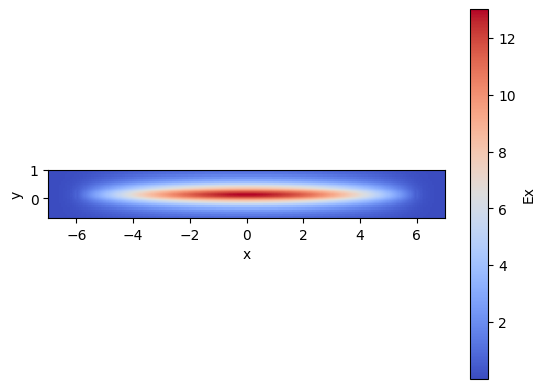

In [32]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

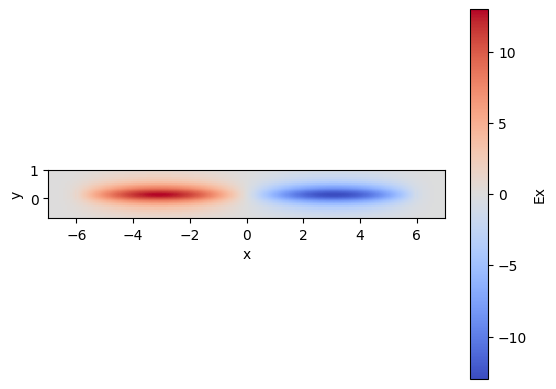

In [33]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

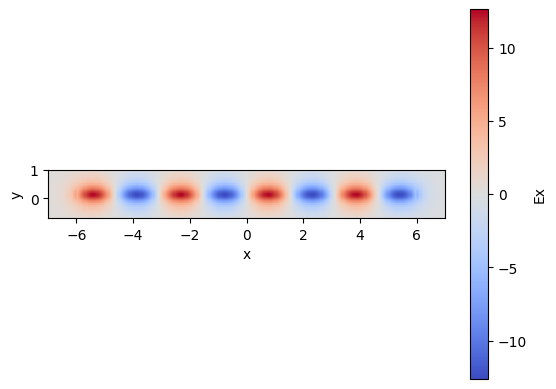

In [34]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [35]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794412975


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [36]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607256687  µm


/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


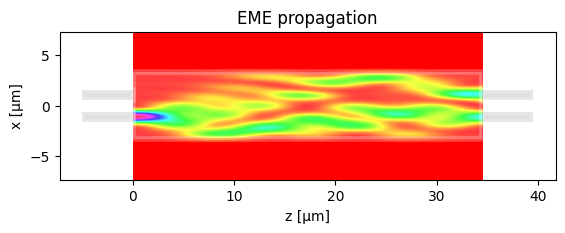

In [37]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9149
Excess loss [dB] =  0.3861
------------------------
Power over OUTs:  ['0.4631', '0.4518']
Ratio over OUTs ['0.5062', '0.4938']


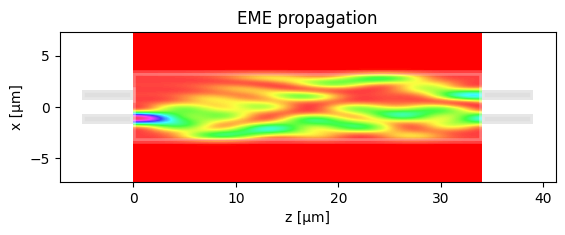

In [38]:
dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.5  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [39]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.75 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607257234  µm


/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.7500
------------------------
Total power IN coupled 0.9926
Total OUT power: 0.9808
Excess loss [dB] =  0.0841
------------------------
Power over OUTs:  ['0.4992', '0.4817']
Ratio over OUTs ['0.5089', '0.4911']


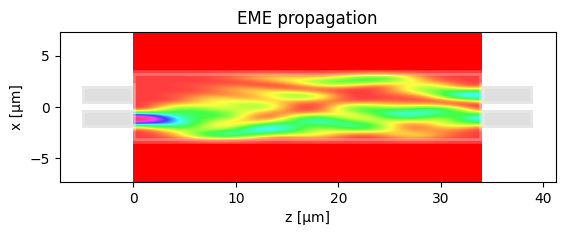

In [40]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [41]:

# 1x4 MMI design flow
mmi_Width = 12.0  # STUDENT. Body width increased to accommodate 4 outputs
m = MMI_EME()
m.MMI_width = mmi_Width
m.wg_width_dw = 1  # STUDENT. make waveguides slightly wider

# 1) Compute the MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")


/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  219.1393154408483  µm


/home/jorge/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/806 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -0.8000
IO wg width 1.0000
IO wg width increment 1.0000
------------------------
Total power IN coupled 0.9935
Total OUT power: 0.9816
Excess loss [dB] =  0.0807
------------------------
Power over OUTs:  ['0.2390', '0.2518', '0.2518', '0.2389']
Ratio over OUTs ['0.2435', '0.2565', '0.2566', '0.2434']


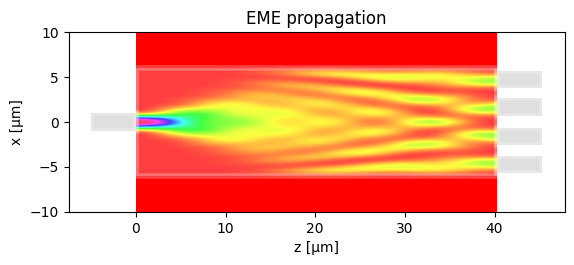

In [42]:

# 3) Configure 1x4 MMI
m.n_IN = 1  # STUDENT
m.n_OUT = 4  # STUDENT

# MMI I/O positions: input at center, outputs evenly spaced
m.IN_WVG_positions = np.array([0.0])  # center
d_extremos = 0.02 #ajuste para las guías exteriores
d_internos = 0.01 #ajuste para las guías anteriores
m.OUT_WVG_positions = mmi_Width * np.array([-3/8 - d_extremos, -1/8 - d_internos, 1/8 + d_internos, 3/8 + d_extremos])

# MMI length
m.L_MMI = (3* L_pi)/ (4*4) # STUDENT. Se aplica la fórmula para 4 salidas
m.dL_MMI = -0.8  # STUDENT

# Run propagation
m.propagation()


## Extra - Exercises

### E1. Directional coupler gap dependence

Simulando Deep WG - gap = 0.2 um...
2026-05-01 20:19:58.307 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.
Simulando Deep WG - gap = 0.4 um...
2026-05-01 20:19:58.319 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_266d67620f0948f9.npz.
Simulando Deep WG - gap = 0.6 um...
2026-05-01 20:19:58.330 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_fa4c4babd472f540.npz.
Simulando Deep WG - gap = 0.8 um...
2026-05-01 20:19:58.339 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f8167db7728a9ebb.npz.
Simulando Deep WG - gap = 1.0 um...
2026-05-01 20:19:58.346 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b0f701e58db4a1bf.npz.
Simulando Deep WG - gap = 1.2 um...
2026-05-01 20:19:58.356 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_de78bc7bac7ad1

<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:81: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:81: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_13357/1633624398.py:71: SyntaxWarning: invalid escape sequence '\p'
  axes[0].set_title("Deep waveguide: $L_\pi$ vs gap")
/tmp/ipykernel_13357/1633624398.py:81: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_title("Shallow waveguide: $L_\pi$ vs gap (slab = 150 nm)")


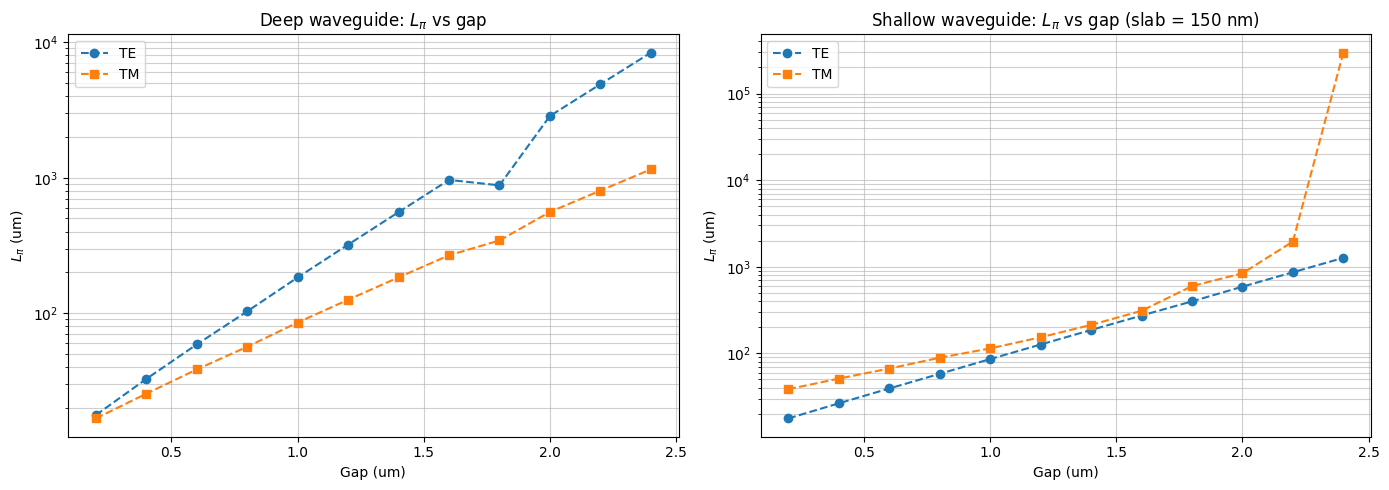


Gap (um)   | Lpi TE Deep     | Lpi TM Deep     | Lpi TE Shallow  | Lpi TM Shallow 
0.2        | 17.69           | 16.72           | 17.71           | 38.52          
0.4        | 32.69           | 25.45           | 26.45           | 51.07          
0.6        | 58.77           | 38.43           | 39.25           | 66.68          
0.8        | 103.11          | 56.51           | 57.95           | 88.93          
1.0        | 183.51          | 85.35           | 85.76           | 113.95         
1.2        | 320.54          | 125.67          | 126.36          | 153.12         
1.4        | 556.78          | 183.82          | 185.87          | 212.84         
1.6        | 963.20          | 267.43          | 273.08          | 309.60         
1.8        | 878.42          | 344.28          | 397.70          | 596.69         
2.0        | 2855.03         | 558.73          | 588.23          | 839.94         
2.2        | 4898.71         | 803.36          | 862.79          | 1951.62        
2.4

In [43]:
# E1. Directional coupler gap dependence
# Lpi vs gap for TE and TM
# Deep waveguide and shallow waveguide with slab = 150 nm

lambda_c = 1.55
wg_width = 1.0
# Usamos un límite superior ligeramente mayor para asegurar que 2.4 esté incluido
gap_values = np.arange(0.2, 2.41, 0.2) 

def calculate_Lpi_vs_gap(slab_thickness, label):
    # Pre-reservamos memoria para mayor eficiencia
    Lpi_TE = np.zeros(len(gap_values))
    Lpi_TM = np.zeros(len(gap_values))

    for idx, gap_to_simulate in enumerate(gap_values):
        print(f"Simulando {label} - gap = {gap_to_simulate:.1f} um...")

        # Llamada al solver de modos
        dc_sim = gt.modes.WaveguideCoupler(
            wavelength=lambda_c,
            core_width=(wg_width, wg_width),
            gap=gap_to_simulate,
            slab_thickness=slab_thickness,
            core_material='sin',
            clad_material='sio2',
            core_thickness=300 * nm, # Asegúrate de que la variable nm esté definida en una celda superior (ej. nm = 1e-3)
            num_modes=4,
            cache_path='.cache/',
            precision='double',
            max_grid_scaling=1.5,
            grid_resolution=20
        )

        n_effs = np.real(dc_sim.n_eff)
        te_fracs = np.array(dc_sim.fraction_te)

        # Clasificación robusta de modos: ordenamos por fracción TE de mayor a menor
        sorted_indices = np.argsort(te_fracs)[::-1]
        
        # Los dos modos con mayor fracción TE serán TE-like
        te0, te1 = sorted_indices[0], sorted_indices[1]
        # Los dos modos con menor fracción TE serán TM-like
        tm0, tm1 = sorted_indices[2], sorted_indices[3]

        # Cálculo de Lpi = lambda / (2 * delta_neff)
        dn_te = np.abs(n_effs[te0] - n_effs[te1])
        dn_tm = np.abs(n_effs[tm0] - n_effs[tm1])

        Lpi_TE[idx] = 0.5 * lambda_c / dn_te
        Lpi_TM[idx] = 0.5 * lambda_c / dn_tm

    return Lpi_TE, Lpi_TM


# --- 1. CÁLCULOS ---
# Deep waveguide (slab = 0)
Lpi_TE_deep, Lpi_TM_deep = calculate_Lpi_vs_gap(slab_thickness=0 * nm, label="Deep WG")

# Shallow waveguide (slab = 150 nm)
Lpi_TE_shallow, Lpi_TM_shallow = calculate_Lpi_vs_gap(slab_thickness=150 * nm, label="Shallow WG")


# --- 2. GRÁFICOS (Subplots para mejor comparación) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Deep
axes[0].plot(gap_values, Lpi_TE_deep, marker="o", linestyle="--", label="TE")
axes[0].plot(gap_values, Lpi_TM_deep, marker="s", linestyle="--", label="TM")
axes[0].set_xlabel("Gap (um)")
axes[0].set_ylabel(r"$L_\pi$ (um)")
axes[0].set_title("Deep waveguide: $L_\pi$ vs gap")
axes[0].grid(True, which="both", ls="-", alpha=0.6)
axes[0].set_yscale("log")
axes[0].legend()

# Plot Shallow
axes[1].plot(gap_values, Lpi_TE_shallow, marker="o", linestyle="--", label="TE")
axes[1].plot(gap_values, Lpi_TM_shallow, marker="s", linestyle="--", label="TM")
axes[1].set_xlabel("Gap (um)")
axes[1].set_ylabel(r"$L_\pi$ (um)")
axes[1].set_title("Shallow waveguide: $L_\pi$ vs gap (slab = 150 nm)")
axes[1].grid(True, which="both", ls="-", alpha=0.6)
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()


# --- 3. IMPRESIÓN DE RESULTADOS (Formato Tabla) ---
print("\n" + "="*85)
print(f"{'Gap (um)':<10} | {'Lpi TE Deep':<15} | {'Lpi TM Deep':<15} | {'Lpi TE Shallow':<15} | {'Lpi TM Shallow':<15}")
print("="*85)

for gap, lte_d, ltm_d, lte_s, ltm_s in zip(gap_values, Lpi_TE_deep, Lpi_TM_deep, Lpi_TE_shallow, Lpi_TM_shallow):
    print(f"{gap:<10.1f} | {lte_d:<15.2f} | {ltm_d:<15.2f} | {lte_s:<15.2f} | {ltm_s:<15.2f}")
print("="*85)

### E2. Directional coupler wavelength dependence

Simulando Deep WG en el rango de longitudes de onda...
2026-05-01 20:20:06.105 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d7fb4453216b17d7.npz.
Simulando Shallow WG en el rango de longitudes de onda...
2026-05-01 20:20:06.118 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8f04dc623f0a74d0.npz.


<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_13357/3070238506.py:62: SyntaxWarning: invalid escape sequence '\p'
  axes[0].set_title("Deep waveguide: $L_\pi$ vs Wavelength")
/tmp/ipykernel_13357/3070238506.py:71: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_title("Shallow waveguide: $L_\pi$ vs Wavelength (slab = 150 nm)")


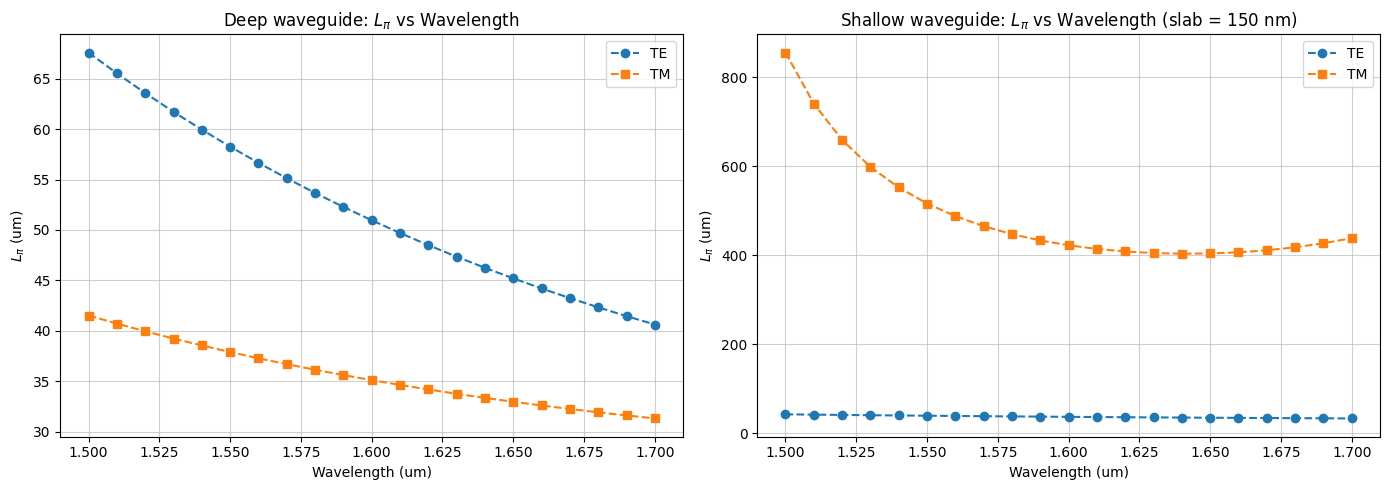


Lambda (um)  | Lpi TE Deep     | Lpi TM Deep     | Lpi TE Shallow  | Lpi TM Shallow 
1.500        | 67.60           | 41.51           | 42.33           | 854.99         
1.510        | 65.54           | 40.71           | 41.66           | 740.45         
1.520        | 63.58           | 39.95           | 41.01           | 658.83         
1.530        | 61.72           | 39.22           | 40.39           | 598.26         
1.540        | 59.95           | 38.54           | 39.80           | 552.02         
1.550        | 58.27           | 37.89           | 39.23           | 516.02         
1.560        | 56.66           | 37.27           | 38.69           | 487.62         
1.570        | 55.13           | 36.69           | 38.17           | 465.08         
1.580        | 53.68           | 36.13           | 37.67           | 447.17         
1.590        | 52.29           | 35.60           | 37.19           | 433.07         
1.600        | 50.96           | 35.10           | 36.73        

In [44]:
# E2. Directional coupler wavelength dependence
# Lpi vs wavelength for TE and TM
# Deep and shallow waveguides

wavelength = np.linspace(1.50, 1.70, 21) # Rango de 1.50 a 1.70 um

wg_width = 1.0
gap = 0.6


def get_Lpi_TE_TM_vs_wavelength(slab_thickness, label):
    print(f"Simulando {label} WG en el rango de longitudes de onda...")
    
    dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength, # Se pasa el vector completo
        core_width=(wg_width, wg_width),
        gap=gap,
        slab_thickness=slab_thickness,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm, # Asegúrate de tener nm definido
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = np.real(dcoupler_cs.n_eff)

    # Manejo de dimensiones dependiendo de la salida del solver
    if neff.shape[0] == len(wavelength):
        neff_TE0, neff_TE1 = neff[:, 0], neff[:, 1]
        neff_TM0, neff_TM1 = neff[:, 2], neff[:, 3]
    else:
        neff_TE0, neff_TE1 = neff[0, :], neff[1, :]
        neff_TM0, neff_TM1 = neff[2, :], neff[3, :]

    # Cálculo de Lpi con valor absoluto por seguridad matemática
    L_pi_TE = 0.5 * wavelength / np.abs(neff_TE0 - neff_TE1)
    L_pi_TM = 0.5 * wavelength / np.abs(neff_TM0 - neff_TM1)

    return L_pi_TE, L_pi_TM


# --- 1. CÁLCULOS ---
# Deep waveguide (slab = 0)
L_pi_TE_deep, L_pi_TM_deep = get_Lpi_TE_TM_vs_wavelength(slab_thickness=0 * nm, label="Deep")

# Shallow waveguide (slab = 150 nm)
L_pi_TE_shallow, L_pi_TM_shallow = get_Lpi_TE_TM_vs_wavelength(slab_thickness=150 * nm, label="Shallow")


# --- 2. GRÁFICOS (Subplots) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Deep
axes[0].plot(wavelength, L_pi_TE_deep, marker="o", linestyle="--", label="TE")
axes[0].plot(wavelength, L_pi_TM_deep, marker="s", linestyle="--", label="TM")
axes[0].set_xlabel("Wavelength (um)")
axes[0].set_ylabel(r"$L_\pi$ (um)")
axes[0].set_title("Deep waveguide: $L_\pi$ vs Wavelength")
axes[0].grid(True, which="both", ls="-", alpha=0.6)
axes[0].legend()

# Plot Shallow
axes[1].plot(wavelength, L_pi_TE_shallow, marker="o", linestyle="--", label="TE")
axes[1].plot(wavelength, L_pi_TM_shallow, marker="s", linestyle="--", label="TM")
axes[1].set_xlabel("Wavelength (um)")
axes[1].set_ylabel(r"$L_\pi$ (um)")
axes[1].set_title("Shallow waveguide: $L_\pi$ vs Wavelength (slab = 150 nm)")
axes[1].grid(True, which="both", ls="-", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()


# --- 3. IMPRESIÓN DE RESULTADOS (Formato Tabla) ---
print("\n" + "="*88)
print(f"{'Lambda (um)':<12} | {'Lpi TE Deep':<15} | {'Lpi TM Deep':<15} | {'Lpi TE Shallow':<15} | {'Lpi TM Shallow':<15}")
print("="*88)

for wl, lte_d, ltm_d, lte_s, ltm_s in zip(wavelength, L_pi_TE_deep, L_pi_TM_deep, L_pi_TE_shallow, L_pi_TM_shallow):
    print(f"{wl:<12.3f} | {lte_d:<15.2f} | {ltm_d:<15.2f} | {lte_s:<15.2f} | {ltm_s:<15.2f}")
print("="*88)

### E3. MMI coupler wavelength dependence

Simulando MMI Deep en el rango de longitudes de onda...
2026-05-01 20:20:12.646 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_766d6c32e1df6a32.npz.
  -> Índices de modos TE utilizados: 0, 1
  -> Índices de modos TM utilizados: 5, 6
Simulando MMI Shallow en el rango de longitudes de onda...
2026-05-01 20:20:12.651 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0a9bd126ad0aa88a.npz.


<>:75: SyntaxWarning: invalid escape sequence '\p'
<>:84: SyntaxWarning: invalid escape sequence '\p'
<>:75: SyntaxWarning: invalid escape sequence '\p'
<>:84: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_13357/464599488.py:75: SyntaxWarning: invalid escape sequence '\p'
  axes[0].set_title("Deep MMI: $L_\pi$ vs Wavelength")
/tmp/ipykernel_13357/464599488.py:84: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_title("Shallow MMI: $L_\pi$ vs Wavelength (slab = 150 nm)")


  -> Índices de modos TE utilizados: 0, 1
  -> Índices de modos TM utilizados: 5, 6


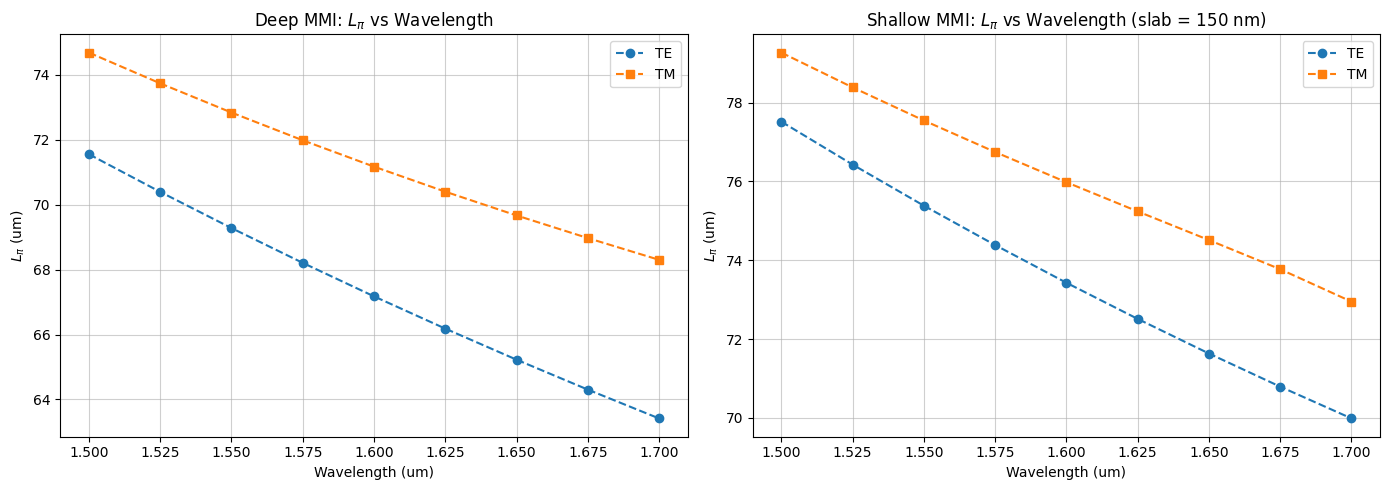


Lambda (um)  | Lpi TE Deep     | Lpi TM Deep     | Lpi TE Shallow  | Lpi TM Shallow 
1.500        | 71.55           | 74.68           | 77.52           | 79.27          
1.525        | 70.39           | 73.74           | 76.43           | 78.39          
1.550        | 69.28           | 72.84           | 75.38           | 77.55          
1.575        | 68.21           | 71.98           | 74.39           | 76.75          
1.600        | 67.18           | 71.17           | 73.43           | 75.98          
1.625        | 66.18           | 70.40           | 72.51           | 75.24          
1.650        | 65.23           | 69.67           | 71.63           | 74.51          
1.675        | 64.30           | 68.97           | 70.79           | 73.77          
1.700        | 63.42           | 68.30           | 69.99           | 72.95          


In [45]:
# E3. MMI coupler wavelength dependence
# Lpi vs wavelength for TE and TM
# Deep and shallow MMI body

mmi_body_w = 6.6
# Mantenemos los 9 puntos de simulacion del compañero
lambda_c = np.linspace(1.50, 1.70, 9) 


def calculate_MMI_Lpi_vs_wavelength(slab_thickness, label):
    print(f"Simulando MMI {label} en el rango de longitudes de onda...")

    mmi_body_waveguide = gt.modes.Waveguide(
        core_width=mmi_body_w,
        core_thickness=300 * nm, 
        slab_thickness=slab_thickness,
        core_material='sin',
        clad_material='sio2',
        wavelength=lambda_c,
        num_modes=20,            
        max_grid_scaling=1.5,
        grid_resolution=15,
        cache_path='.cache/',
        precision='double',
    )

    neff = np.real(mmi_body_waveguide.n_eff)
    fraction_te = np.array(mmi_body_waveguide.fraction_te)

    if neff.shape[0] != len(lambda_c):
        neff = neff.T

    # Promediamos la fracción TE si es una matriz 2D para ser robustos
    if fraction_te.ndim > 1:
        if fraction_te.shape[0] != len(lambda_c):
            fraction_te = fraction_te.T
        te_fracs = np.mean(fraction_te, axis=0)
    else:
        te_fracs = fraction_te

    # CORRECCIÓN: Filtramos manteniendo el orden original del solver (por n_eff)
    te_modes = np.where(te_fracs > 0.5)[0]
    tm_modes = np.where(te_fracs <= 0.5)[0]

    # Los dos primeros de la lista filtrada serán los fundamentales (mayor n_eff)
    te0, te1 = te_modes[0], te_modes[1]
    tm0, tm1 = tm_modes[0], tm_modes[1]

    print(f"  -> Índices de modos TE utilizados: {te0}, {te1}")
    print(f"  -> Índices de modos TM utilizados: {tm0}, {tm1}")

    # Cálculo de Lpi
    Lpi_TE = 0.5 * lambda_c / np.abs(neff[:, te0] - neff[:, te1])
    Lpi_TM = 0.5 * lambda_c / np.abs(neff[:, tm0] - neff[:, tm1])

    return Lpi_TE, Lpi_TM


# --- 1. CÁLCULOS ---
# Deep MMI (slab = 0)
Lpi_TE_deep, Lpi_TM_deep = calculate_MMI_Lpi_vs_wavelength(slab_thickness=0 * nm, label="Deep")

# Shallow MMI (slab = 150 nm)
Lpi_TE_shallow, Lpi_TM_shallow = calculate_MMI_Lpi_vs_wavelength(slab_thickness=150 * nm, label="Shallow")


# --- 2. GRÁFICOS (Subplots) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Deep MMI
axes[0].plot(lambda_c, Lpi_TE_deep, marker="o", linestyle="--", label="TE")
axes[0].plot(lambda_c, Lpi_TM_deep, marker="s", linestyle="--", label="TM")
axes[0].set_xlabel("Wavelength (um)")
axes[0].set_ylabel(r"$L_\pi$ (um)")
axes[0].set_title("Deep MMI: $L_\pi$ vs Wavelength")
axes[0].grid(True, which="both", ls="-", alpha=0.6)
axes[0].legend()

# Plot Shallow MMI
axes[1].plot(lambda_c, Lpi_TE_shallow, marker="o", linestyle="--", label="TE")
axes[1].plot(lambda_c, Lpi_TM_shallow, marker="s", linestyle="--", label="TM")
axes[1].set_xlabel("Wavelength (um)")
axes[1].set_ylabel(r"$L_\pi$ (um)")
axes[1].set_title("Shallow MMI: $L_\pi$ vs Wavelength (slab = 150 nm)")
axes[1].grid(True, which="both", ls="-", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()


# --- 3. IMPRESIÓN DE RESULTADOS (Formato Tabla) ---
print("\n" + "="*88)
print(f"{'Lambda (um)':<12} | {'Lpi TE Deep':<15} | {'Lpi TM Deep':<15} | {'Lpi TE Shallow':<15} | {'Lpi TM Shallow':<15}")
print("="*88)

for wl, lte_d, ltm_d, lte_s, ltm_s in zip(lambda_c, Lpi_TE_deep, Lpi_TM_deep, Lpi_TE_shallow, Lpi_TM_shallow):
    print(f"{wl:<12.3f} | {lte_d:<15.2f} | {ltm_d:<15.2f} | {lte_s:<15.2f} | {ltm_s:<15.2f}")
print("="*88)

### E4. MMI coupler body width dependence

Simulando Deep MMI - width = 5.0 um...
2026-05-01 20:20:18.794 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ec30668a999b902b.npz.
Simulando Deep MMI - width = 5.5 um...
2026-05-01 20:20:18.799 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c0fb452d8d9c70db.npz.
Simulando Deep MMI - width = 6.0 um...
2026-05-01 20:20:18.802 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f21f6bf05eca73ee.npz.
Simulando Deep MMI - width = 6.5 um...
2026-05-01 20:20:18.805 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1b1c56ba0da14ecb.npz.
Simulando Deep MMI - width = 7.0 um...
2026-05-01 20:20:18.807 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ea749a746e45894f.npz.
Simulando Deep MMI - width = 7.5 um...
2026-05-01 20:20:18.812 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a23340a2a969d1ab.npz.
Simulando Deep M

<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:80: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_13357/3772008593.py:71: SyntaxWarning: invalid escape sequence '\p'
  axes[0].set_title("Deep MMI: $L_\pi$ vs Body Width")
/tmp/ipykernel_13357/3772008593.py:80: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_title("Shallow MMI: $L_\pi$ vs Body Width (slab = 150 nm)")


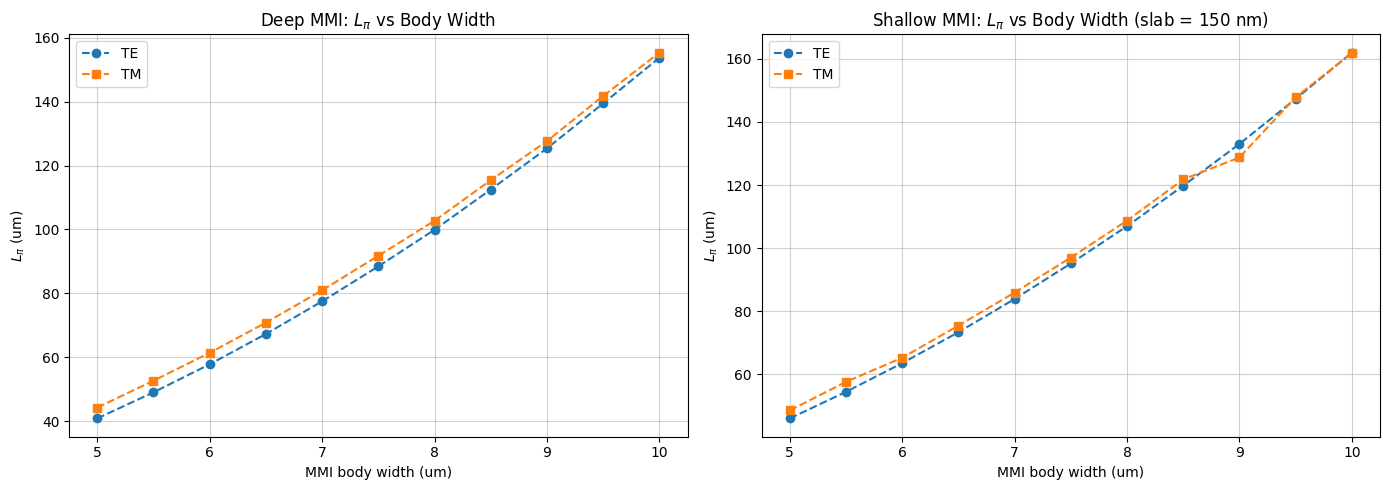


Width (um)   | Lpi TE Deep     | Lpi TM Deep     | Lpi TE Shallow  | Lpi TM Shallow 
5.0          | 40.83           | 44.22           | 46.00           | 48.54          
5.5          | 49.01           | 52.64           | 54.44           | 57.59          
6.0          | 57.78           | 61.38           | 63.53           | 65.25          
6.5          | 67.28           | 70.83           | 73.34           | 75.42          
7.0          | 77.50           | 80.95           | 83.88           | 85.92          
7.5          | 88.45           | 91.76           | 95.13           | 97.01          
8.0          | 99.90           | 102.73          | 106.97          | 108.72         
8.5          | 112.51          | 115.44          | 119.79          | 121.79         
9.0          | 125.39          | 127.68          | 133.05          | 128.75         
9.5          | 139.47          | 141.80          | 147.33          | 147.85         
10.0         | 153.77          | 155.37          | 161.99       

In [46]:
# E4. MMI coupler body width dependence
# Lpi vs MMI body width for TE and TM
# Deep and shallow MMI body

lambda_c = 1.55
# np.arange(5.0, 10.5, 0.5) asegura que llegue hasta 10.0
mmi_width_values = np.arange(5.0, 10.5, 0.5) 

def calculate_MMI_Lpi_vs_width(slab_thickness, label):
    # Pre-reservamos memoria
    Lpi_TE = np.zeros(len(mmi_width_values))
    Lpi_TM = np.zeros(len(mmi_width_values))

    for idx, mmi_body_w in enumerate(mmi_width_values):
        print(f"Simulando {label} MMI - width = {mmi_body_w:.1f} um...")

        mmi_body_waveguide = gt.modes.Waveguide(
            core_width=mmi_body_w,
            core_thickness=300 * nm, # Asegúrate de tener nm definido
            slab_thickness=slab_thickness,
            core_material='sin',
            clad_material='sio2',
            wavelength=lambda_c,
            num_modes=20,            # Mantenemos 20 modos por la gran anchura
            max_grid_scaling=1.5,
            grid_resolution=15,
            cache_path='.cache/',
            precision='double',
        )

        neff = np.real(mmi_body_waveguide.n_eff)
        fraction_te = np.array(mmi_body_waveguide.fraction_te)

        # Forzamos array 1D si el solver devuelve matriz 2D para una sola longitud de onda
        if neff.ndim > 1:
            neff = neff[:, 0]
        if fraction_te.ndim > 1:
            fraction_te = fraction_te[:, 0]

        # SELECCIÓN ROBUSTA: Mantiene el orden descendente de n_eff del solver
        te_modes = np.where(fraction_te > 0.5)[0]
        tm_modes = np.where(fraction_te <= 0.5)[0]

        # Tomamos los dos primeros de cada lista (los de mayor n_eff)
        te0, te1 = te_modes[0], te_modes[1]
        tm0, tm1 = tm_modes[0], tm_modes[1]

        # Cálculo con valor absoluto por seguridad
        Lpi_TE[idx] = 0.5 * lambda_c / np.abs(neff[te0] - neff[te1])
        Lpi_TM[idx] = 0.5 * lambda_c / np.abs(neff[tm0] - neff[tm1])

    return Lpi_TE, Lpi_TM


# --- 1. CÁLCULOS ---
# Deep MMI (slab = 0)
Lpi_TE_deep, Lpi_TM_deep = calculate_MMI_Lpi_vs_width(slab_thickness=0 * nm, label="Deep")

# Shallow MMI (slab = 150 nm)
Lpi_TE_shallow, Lpi_TM_shallow = calculate_MMI_Lpi_vs_width(slab_thickness=150 * nm, label="Shallow")


# --- 2. GRÁFICOS (Subplots) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Deep MMI
axes[0].plot(mmi_width_values, Lpi_TE_deep, marker="o", linestyle="--", label="TE")
axes[0].plot(mmi_width_values, Lpi_TM_deep, marker="s", linestyle="--", label="TM")
axes[0].set_xlabel("MMI body width (um)")
axes[0].set_ylabel(r"$L_\pi$ (um)")
axes[0].set_title("Deep MMI: $L_\pi$ vs Body Width")
axes[0].grid(True, which="both", ls="-", alpha=0.6)
axes[0].legend()

# Plot Shallow MMI
axes[1].plot(mmi_width_values, Lpi_TE_shallow, marker="o", linestyle="--", label="TE")
axes[1].plot(mmi_width_values, Lpi_TM_shallow, marker="s", linestyle="--", label="TM")
axes[1].set_xlabel("MMI body width (um)")
axes[1].set_ylabel(r"$L_\pi$ (um)")
axes[1].set_title("Shallow MMI: $L_\pi$ vs Body Width (slab = 150 nm)")
axes[1].grid(True, which="both", ls="-", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()


# --- 3. BÚSQUEDA DE PUNTOS ÓPTIMOS Y RESULTADOS ---
deep_diff = np.abs(Lpi_TE_deep - Lpi_TM_deep)
deep_best_idx = np.argmin(deep_diff)

shallow_diff = np.abs(Lpi_TE_shallow - Lpi_TM_shallow)
shallow_best_idx = np.argmin(shallow_diff)

print("\n" + "="*85)
print(f"{'Width (um)':<12} | {'Lpi TE Deep':<15} | {'Lpi TM Deep':<15} | {'Lpi TE Shallow':<15} | {'Lpi TM Shallow':<15}")
print("="*85)

for w, lte_d, ltm_d, lte_s, ltm_s in zip(mmi_width_values, Lpi_TE_deep, Lpi_TM_deep, Lpi_TE_shallow, Lpi_TM_shallow):
    print(f"{w:<12.1f} | {lte_d:<15.2f} | {ltm_d:<15.2f} | {lte_s:<15.2f} | {ltm_s:<15.2f}")
print("="*85)

# Imprimir los puntos óptimos (menor diferencia entre polarizaciones)
print("\n" + "*"*45)
print("** PUNTO ÓPTIMO DE POLARIZACIÓN (DEEP) **")
print("*"*45)
print(f"Ancho óptimo = {mmi_width_values[deep_best_idx]:.1f} um")
print(f"Lpi TE       = {Lpi_TE_deep[deep_best_idx]:.2f} um")
print(f"Lpi TM       = {Lpi_TM_deep[deep_best_idx]:.2f} um")
print(f"Diferencia   = {deep_diff[deep_best_idx]:.2f} um")

print("\n" + "*"*45)
print("** PUNTO ÓPTIMO DE POLARIZACIÓN (SHALLOW) **")
print("*"*45)
print(f"Ancho óptimo = {mmi_width_values[shallow_best_idx]:.1f} um")
print(f"Lpi TE       = {Lpi_TE_shallow[shallow_best_idx]:.2f} um")
print(f"Lpi TM       = {Lpi_TM_shallow[shallow_best_idx]:.2f} um")
print(f"Diferencia   = {shallow_diff[shallow_best_idx]:.2f} um")
print("*"*45)

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points